# Part A – Understanding LLM Types
**Objective:** Compare a Small Language Model (SLM) and a Dense Language Model on model size, parameters, memory usage, and output quality.

- **SLM:** DistilGPT-2 (~82M parameters)
- **Dense LM:** GPT-2 Medium (~355M parameters)

## 1. Setup & GPU Check

In [1]:
import torch
import pandas as pd
import time
import tracemalloc
from transformers import AutoTokenizer, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("No GPU found, using CPU")
print(f"Using device: {device}")

d:\college\VI-sem\DL\lab-task-3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GeForce RTX 5070 Laptop GPU (8.0 GB)
Using device: cuda


## 2. Define Models to Compare

In [2]:
models_config = {
    "DistilGPT-2 (SLM)": "distilgpt2",
    "GPT-2 Medium (Dense)": "gpt2-medium"
}

## 3. Helper Functions

In [3]:
def count_parameters(model):
    """Count total and trainable parameters."""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def get_model_size_mb(model):
    """Get model size in MB (based on parameter memory)."""
    param_size = sum(p.numel() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.numel() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / (1024 ** 2)

def get_gpu_memory_used():
    """Get current GPU memory allocated in MB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / (1024 ** 2)
    return 0.0

def generate_text(model, tokenizer, prompt, max_new_tokens=100):
    """Generate text from a prompt and measure inference time."""
    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )
    
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    elapsed = time.time() - start
    
    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return generated, elapsed

## 4. Load Models & Collect Metrics

In [4]:
results = []

test_prompts = [
    "Artificial intelligence is transforming the world by",
    "The future of education depends on",
    "Climate change can be addressed through"
]

generated_outputs = {}  # store outputs for quality comparison

for model_name, model_id in models_config.items():
    print(f"\n{'='*60}")
    print(f"Loading: {model_name} ({model_id})")
    print(f"{'='*60}")
    
    # Clear GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    model = AutoModelForCausalLM.from_pretrained(model_id).to(device)
    model.eval()
    
    # --- Metrics ---
    total_params, trainable_params = count_parameters(model)
    model_size = get_model_size_mb(model)
    gpu_mem_used = get_gpu_memory_used()
    num_layers = model.config.n_layer
    hidden_size = model.config.n_embd
    vocab_size = model.config.vocab_size
    
    print(f"  Total Parameters : {total_params:,}")
    print(f"  Model Size       : {model_size:.1f} MB")
    print(f"  GPU Memory Used  : {gpu_mem_used:.1f} MB")
    print(f"  Layers           : {num_layers}")
    print(f"  Hidden Size      : {hidden_size}")
    print(f"  Vocab Size       : {vocab_size}")
    
    # --- Generate outputs ---
    generated_outputs[model_name] = []
    total_inference_time = 0
    
    for prompt in test_prompts:
        output, t = generate_text(model, tokenizer, prompt, max_new_tokens=80)
        generated_outputs[model_name].append((prompt, output))
        total_inference_time += t
    
    avg_inference_time = total_inference_time / len(test_prompts)
    print(f"  Avg Inference Time: {avg_inference_time:.2f}s")
    
    # Store results
    results.append({
        "Model": model_name,
        "Model ID": model_id,
        "Total Parameters": f"{total_params:,}",
        "Layers": num_layers,
        "Hidden Size": hidden_size,
        "Vocab Size": vocab_size,
        "Model Size (MB)": round(model_size, 1),
        "GPU Memory (MB)": round(gpu_mem_used, 1),
        "Avg Inference Time (s)": round(avg_inference_time, 2)
    })
    
    # Free memory
    del model, tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nDone loading and benchmarking both models.")


Loading: DistilGPT-2 (SLM) (distilgpt2)
  Total Parameters : 81,912,576
  Model Size       : 318.5 MB
  GPU Memory Used  : 319.2 MB
  Layers           : 6
  Hidden Size      : 768
  Vocab Size       : 50257
  Avg Inference Time: 0.93s

Loading: GPT-2 Medium (Dense) (gpt2-medium)


d:\college\VI-sem\DL\lab-task-3\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KARTHIK\.cache\huggingface\hub\models--gpt2-medium. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  Total Parameters : 354,823,168
  Model Size       : 1377.5 MB
  GPU Memory Used  : 1387.3 MB
  Layers           : 24
  Hidden Size      : 1024
  Vocab Size       : 50257
  Avg Inference Time: 1.41s

Done loading and benchmarking both models.


## 5. Comparison Table

In [5]:
df_comparison = pd.DataFrame(results)
df_comparison = df_comparison.set_index("Model")
print("\n" + "="*70)
print("         MODEL COMPARISON TABLE")
print("="*70)
display(df_comparison.T)  # Transpose for better readability


         MODEL COMPARISON TABLE


Model,DistilGPT-2 (SLM),GPT-2 Medium (Dense)
Model ID,distilgpt2,gpt2-medium
Total Parameters,"81,912,576","354,823,168"
Layers,6,24
Hidden Size,768,1024
Vocab Size,50257,50257
Model Size (MB),318.5,1377.5
GPU Memory (MB),319.2,1387.3
Avg Inference Time (s),0.93,1.41


## 6. Output Quality Comparison

In [6]:
for i, prompt in enumerate(test_prompts):
    print(f"\n{'='*70}")
    print(f"PROMPT {i+1}: \"{prompt}\"")
    print(f"{'='*70}")
    for model_name in generated_outputs:
        print(f"\n--- {model_name} ---")
        print(generated_outputs[model_name][i][1])
    print()


PROMPT 1: "Artificial intelligence is transforming the world by"

--- DistilGPT-2 (SLM) ---
Artificial intelligence is transforming the world by making it possible to make its own intelligent AI.







































































--- GPT-2 Medium (Dense) ---
Artificial intelligence is transforming the world by making it smarter, faster, and more flexible. But with so much data on how humans and machines are interacting, how we interact with each other and with the world around us, how our behavior and thoughts affect each other and our environment, and how our brains communicate with each other, it is important to understand how the world works and what it can teach us about ourselves.

In a new


PROMPT 2: "The future of education depends on"

--- DistilGPT-2 (SLM) ---
The future of education depends on the outcome of a referendum on the outcome of a referendum on the outcome of a referendum on the outcome of a referendum on the outcome of a refer

## 7. Visual Comparison – Bar Charts

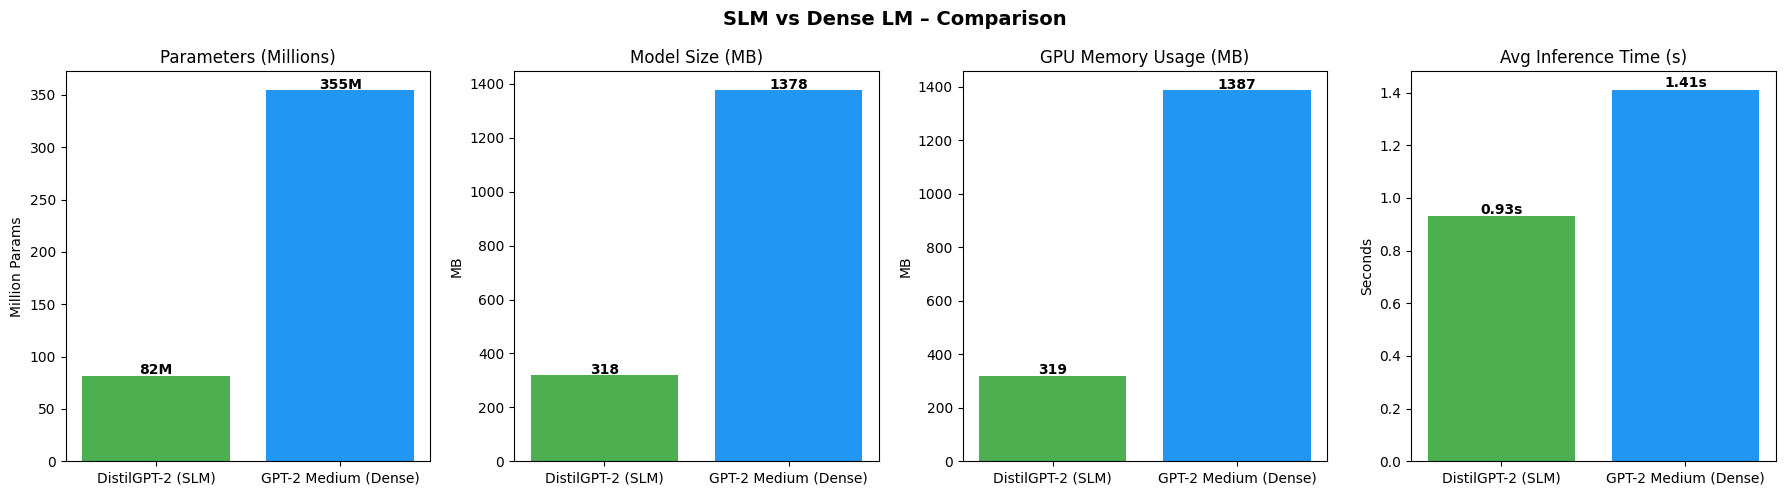

Chart saved as 'part_a_comparison_chart.png'


In [7]:
import matplotlib.pyplot as plt
import numpy as np

model_names = [r["Model"] for r in results]
param_counts = [int(r["Total Parameters"].replace(",", "")) / 1e6 for r in results]
model_sizes = [r["Model Size (MB)"] for r in results]
gpu_mems = [r["GPU Memory (MB)"] for r in results]
inf_times = [r["Avg Inference Time (s)"] for r in results]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
colors = ["#4CAF50", "#2196F3"]

# Parameters
axes[0].bar(model_names, param_counts, color=colors)
axes[0].set_title("Parameters (Millions)")
axes[0].set_ylabel("Million Params")
for j, v in enumerate(param_counts):
    axes[0].text(j, v + 1, f"{v:.0f}M", ha="center", fontweight="bold")

# Model Size
axes[1].bar(model_names, model_sizes, color=colors)
axes[1].set_title("Model Size (MB)")
axes[1].set_ylabel("MB")
for j, v in enumerate(model_sizes):
    axes[1].text(j, v + 5, f"{v:.0f}", ha="center", fontweight="bold")

# GPU Memory
axes[2].bar(model_names, gpu_mems, color=colors)
axes[2].set_title("GPU Memory Usage (MB)")
axes[2].set_ylabel("MB")
for j, v in enumerate(gpu_mems):
    axes[2].text(j, v + 5, f"{v:.0f}", ha="center", fontweight="bold")

# Inference Time
axes[3].bar(model_names, inf_times, color=colors)
axes[3].set_title("Avg Inference Time (s)")
axes[3].set_ylabel("Seconds")
for j, v in enumerate(inf_times):
    axes[3].text(j, v + 0.01, f"{v:.2f}s", ha="center", fontweight="bold")

plt.suptitle("SLM vs Dense LM – Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("part_a_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as 'part_a_comparison_chart.png'")